# 1.라이브러리 및 데이터 불러오기

- credit card 데이터 세트 PCA 변환
    - https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

In [5]:
# pip install xlrd>=2.0.1

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_excel('data1/pca_credit_card.xls', header=1, sheet_name='Data')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [8]:
df.drop('ID', axis=1, inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_AMT4        

# 2.데이터 전처리

In [10]:
df.rename(columns={'PAY_0':'PAY_1', 'default payment next month':'default'}, inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [13]:
X = df.drop('default', axis=1)
y = df['default']

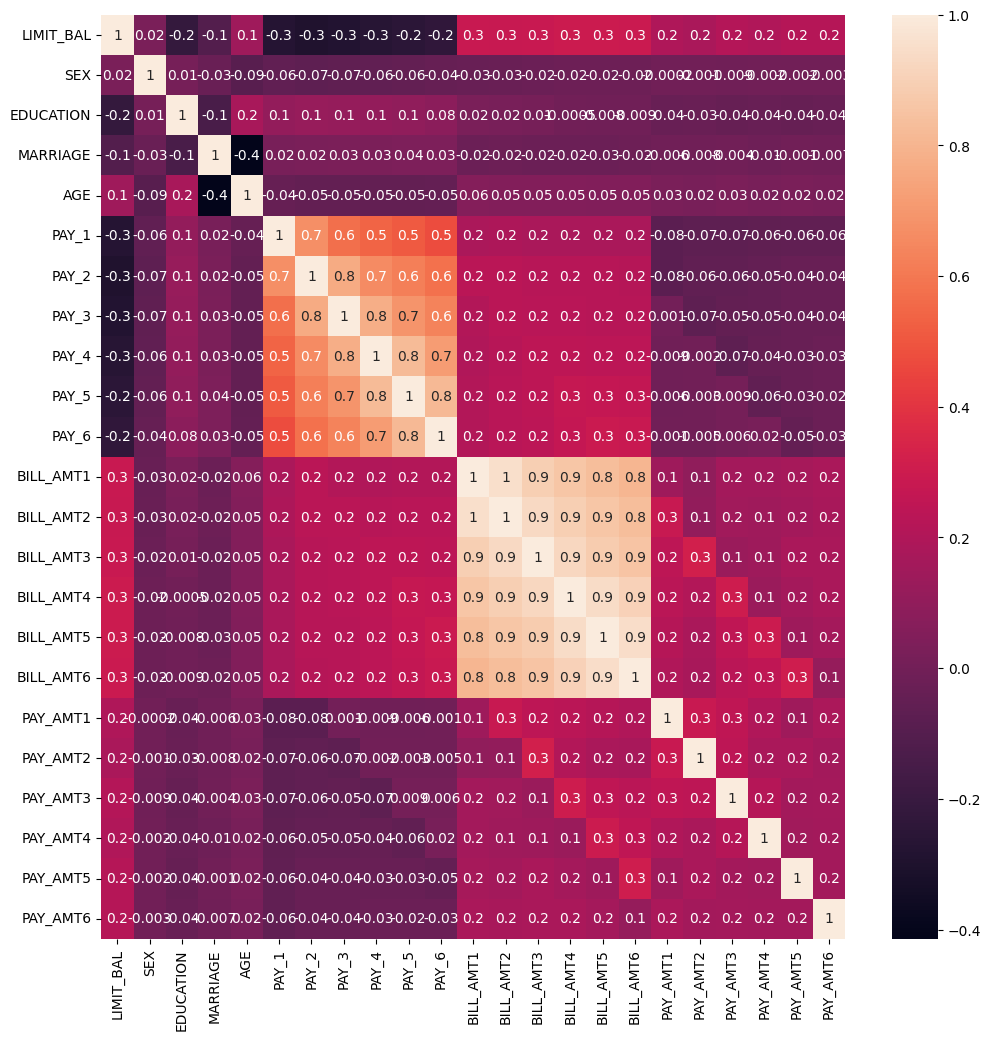

In [14]:
corr = X.corr()

plt.figure(figsize=(12,12))
sns.heatmap(
    corr, 
    annot=True,     # annot=True: 각 셀에 상관계수 값 표시
    fmt='.1g'       # fmt='.1g': 소수점 첫째자리까지 표시
    )
plt.show()

In [ ]:
# BILL_AMT1 ~ BILL_AMT6 까지 6개의 속성
X.iloc[:, 11:17]

# 3.스케일링

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X.iloc[:, 11:17])
X_scaled = scaler.transform(X.iloc[:, 11:17])
X_scaled

array([[-0.64250107, -0.64739923, -0.66799331, -0.67249727, -0.66305853,
        -0.65272422],
       [-0.65921875, -0.66674657, -0.63925429, -0.62163594, -0.60622927,
        -0.59796638],
       [-0.29855966, -0.49389911, -0.48240819, -0.44973025, -0.41718767,
        -0.39162956],
       ...,
       [-0.64722711, -0.64383044, -0.63815838, -0.34796096, -0.32451732,
        -0.32768664],
       [-0.71798186,  0.41026929,  0.42237335,  0.14784373, -0.46806261,
         0.16913036],
       [-0.04473888, -0.00385085,  0.03966713, -0.10458204, -0.12966943,
        -0.39559241]], shape=(30000, 6))

# 4.PCA

In [ ]:
from sklearn.decomposition import PCA

# 원래 6차원 데이터(11~16번째 컬럼)를 2차원으로 압축
pca = PCA(n_components=2)

# PCA 모델 학습, 이 과정에서 스케일링된 데이터를 사용하여 주성분을 찾음.
pca.fit(X_scaled)

# 학습된 PCA 모델을 사용해서 원본 데이터를 주성분 공간으로 변환.
X_pca = pca.transform(X_scaled)
X_pca

array([[-1.61114812,  0.01247912],
       [-1.54759523, -0.06234401],
       [-1.03587378,  0.01125622],
       ...,
       [-1.19551872, -0.3595072 ],
       [-0.00829343, -0.04995798],
       [-0.25828552,  0.26525237]], shape=(30000, 2))

In [ ]:
# 각 주성분이 원본 데이터의 분산을 얼마나 설명하는지 비율로 표시
# 단 2개의 PCA 컴포넌트만으로도 6개 속성의 변동성을 약 95% 이상 설명할 수 있으며, 특히 첫 번째 PCA 축으로 90%의 변동성을 수용할 정도로 이 6개 속성의 
pca.explained_variance_ratio_

array([0.90555253, 0.0509867 ])

# 5.랜덤포레스트와 비교

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rfc = RandomForestClassifier(n_estimators=400, random_state=1)
scores = cross_val_score(rfc, X, y, scoring='accuracy', cv=5)

print(scores)
print(np.mean(scores))

[0.80483333 0.808      0.82183333 0.82916667 0.81983333]
0.8167333333333333


In [19]:
# PCA로 데이터 전처리 후 랜덤포레스트
# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=6)
pca_df = pca.fit_transform(X_scaled)
pca_scores = cross_val_score(rfc, pca_df, y, scoring='accuracy', cv=5)

print(pca_scores)
print(np.mean(pca_scores))

[0.78933333 0.78866667 0.79566667 0.80383333 0.8045    ]
0.7964


- 전체 23개 속성(변수)의 약 1/4 수준인 6개의 PCA 컴포넌트만으로도 원본 데이터를 기반으로 한 분류 예측 결과보다 약 1~2% 정도의 예측 성능 저하만 발생
- 1~2% 예측 성능 저하는 미비한 성능 저하로 보기는 힘들지만, 전체 속성의 1/4 정도만으로도 이 정도 수치의 예측 성능을 유지할 수 있다는 것은 PCA의 뛰어난 압축 능력을 잘 보여주는 것.
- PCA는 차원 축소를 통해 데이터를 쉽게 인지하는 데 활용할 수 있고, 이보다 더 활발하게 적용되는 영역은 컴퓨터 비전 분야
- 특히 얼굴 인식의 경우 PCA 변환으로 원본 얼굴 이미지를 변환해 사용하는 경우가 많음.